# Custom scenarios: what this port can express that the original cannot

The original Tennessee Eastman Fortran offers one kind of experiment. You set some of the
twenty `IDV` flags to 1, you run, and you get a file. A disturbance is on or off, it is on
from whenever you set the flag until the run ends, there is one integrator, and the
description of what you did lives in whatever you wrote in your lab notebook.

This port keeps all of that bit-for-bit and adds four things that a fault detection or
control study usually wants:

- a **schedule**, so a disturbance can arrive at a stated time and clear again,
- **composition**, so several disturbances can be described independently rather than as
  one combined flag set,
- **continuous magnitudes**, so a fault can be applied at a fraction of its full strength,
  which the original genuinely cannot express,
- a **choice of integrator**, so a study that cares about accuracy rather than fidelity to
  the Fortran can have it.

All four are carried in the scenario's canonical text form, which is the subject of the
first section, because none of it is worth much if the description of a run cannot travel
with the run.

*References for this notebook are listed at the bottom.*

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

import tepsim as tep

plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 3.0),
                     "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

print("tepsim", tep.__version__)

tepsim 0.0.0


## A run described by one line of text

Every scenario renders to a single semicolon-separated line, and parses back from it to an
equal scenario, with every floating point field equal by bit pattern. The version tag at
the front is the same string the digest absorbs, so the two cannot drift: adding a field to
a scenario changes both at once, and a text written by an older build is rejected by name
rather than defaulted silently.

The format is deliberately restricted to characters a URL fragment carries without
percent-encoding, so a whole experiment fits in a link.

In [2]:
base = tep.Scenario.baseline(hours=18)
print(base.to_text())
print()
print("digest      ", base.digest)
print("steps       ", base.steps)
print("samples     ", base.samples)
print("round-trips ", tep.Scenario.from_text(base.to_text()) == base)

tepsim.scenario.v1;seed=4651207995;hours=18;step=2.777777777777778e-4;every=180;faults=;controlled=1;idv12=0;trip=1;continuous=0;integrator=euler;events=

digest       64aa88e3de5cf13c
steps        64800
samples      360
round-trips  True


The keys map one to one onto the fields of the scenario: `seed`, `hours`, `step`, `every`
(the sampling cadence in integrator steps), `faults`, `controlled`, `idv12` (whether the
original driver's forced `IDV(12)` at hour eight is reproduced), `trip` (whether a
shutdown ends the run), `continuous`, `integrator` and `events`.

The Python constructors reach eight of those eleven. The remaining three, `continuous`,
`integrator` and `events`, along with anything else added later, are reached through the
text. That is the whole mechanism used below: render, edit, parse. The helper is worth
writing once because editing by string replacement is easy to get subtly wrong.

In [3]:
KEYS = ["seed", "hours", "step", "every", "faults", "controlled", "idv12",
        "trip", "continuous", "integrator", "events"]


def edited(scenario, **changes):
    "`scenario` with the named text fields replaced. Values are strings."
    version, *pairs = scenario.to_text().split(";")
    fields = dict(pair.split("=", 1) for pair in pairs)
    unknown = set(changes) - set(KEYS)
    if unknown:
        raise KeyError("not scenario fields: %s" % sorted(unknown))
    fields.update({k: str(v) for k, v in changes.items()})
    return tep.Scenario.from_text(";".join([version] + ["%s=%s" % (k, fields[k])
                                                        for k in KEYS]))


print(edited(base, events="6:start:4,12:stop:4", hours="18").to_text())

tepsim.scenario.v1;seed=4651207995;hours=18;step=2.777777777777778e-4;every=180;faults=;controlled=1;idv12=0;trip=1;continuous=0;integrator=euler;events=6:start:4,12:stop:4


### `repr` in its two shapes

`Scenario.__repr__` is documented to round-trip, and it does, but not by printing a
constructor call in every case. `Scenario(...)` cannot reach three of the fields a
scenario carries, so a `repr` that printed only the constructor's arguments produced valid
Python that evaluated to a *different* scenario, with a different digest and a different
run, and said nothing about it.

So a scenario the constructor can express prints as a constructor call, because that is
what is readable at a prompt, and anything else prints as `Scenario.from_text(...)`, which
round-trips by construction. Both shapes satisfy `eval(repr(s)) == s`. The cell below
checks the second shape rather than taking it on trust, which is worth doing: the digest
is what would catch a `repr` that lost a field, and it is printed here for both.

In [4]:
from tepsim import Scenario          # repr() names the class, so eval needs it in scope

scheduled = edited(base, events="6:start:4,12:stop:4")
restored = eval(repr(scheduled))

print("repr:", repr(scheduled))
print()
print("eval(repr(s)) == s :", restored == scheduled)
print("digest of s        :", scheduled.digest)
print("digest of the copy :", restored.digest)
print()
print("to_text round-trip :", tep.Scenario.from_text(scheduled.to_text()) == scheduled)

repr: Scenario.from_text("tepsim.scenario.v1;seed=4651207995;hours=18;step=2.777777777777778e-4;every=180;faults=;controlled=1;idv12=0;trip=1;continuous=0;integrator=euler;events=6:start:4,12:stop:4")

eval(repr(s)) == s : True
digest of s        : 77796f4123c9ca6f
digest of the copy : 77796f4123c9ca6f

to_text round-trip : True


## Scheduling: a fault that arrives and clears

An event is `time:verb` followed by the verb's own fields. `8:start:6` switches `IDV(6)` on
at hour 8; `20:stop:6` switches it off at hour 20.

This is the single most useful addition for a monitoring study. A detector is judged on
what it does at the onset, and a fault that is on from the first sample has no onset. It
also makes the recovery half of the problem expressible: the plant after a fault clears is
not the plant before it arrived, because the controllers have moved and the reactor has a
different inventory.

`IDV(4)` is a 5 C step in the reactor cooling water inlet temperature, which the controller
absorbs into the cooling water valve. Watch `XMV(10)` step up when the fault arrives and
come back down when it clears, while the reactor temperature it is defending never moves.

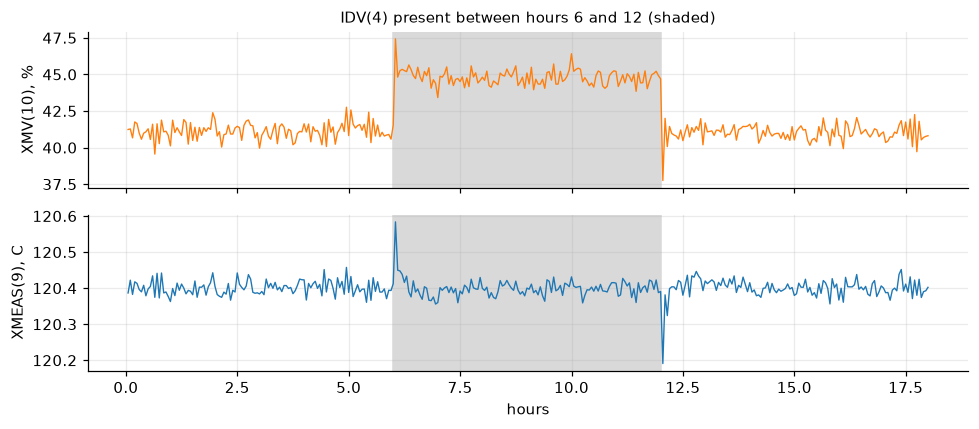

  hours   IDV(4) active   hours since onset   XMV(10)
   4.05       False              never        41.063
   6.55       True               0.55         45.492
   9.05       True               3.05         44.348
  11.95       True               5.95         44.918
  12.55       False              never        41.045
  15.05       False              never        41.106


In [5]:
window = edited(base, hours="18", events="6:start:4,12:stop:4")
run = tep.Simulation(window).run()
labels = run.labels()

fig, axes = plt.subplots(2, 1, figsize=(9, 4.0), sharex=True)
axes[0].plot(run.hours, run.manipulated(10), lw=0.9, color="tab:orange")
axes[0].set_ylabel("XMV(10), %")
axes[0].set_title("IDV(4) present between hours 6 and 12 (shaded)", fontsize=10)
axes[1].plot(run.hours, run.measurement(9), lw=0.9, color="tab:blue")
axes[1].set_ylabel("XMEAS(9), C")
axes[1].set_xlabel("hours")
for ax in axes:
    ax.axvspan(6.0, 12.0, color="0.85", zorder=0)
fig.tight_layout()
plt.show()

print("  hours   IDV(4) active   hours since onset   XMV(10)")
for hour in (4.0, 6.5, 9.0, 11.9, 12.5, 15.0):
    i = int(np.searchsorted(run.hours, hour))
    since = labels["since_onset"][i, 3]
    print("  %5.2f       %-5s              %-7s      %6.3f"
          % (run.hours[i], labels["active"][i, 3],
             "never" if np.isnan(since) else "%.2f" % since, run.manipulated(10)[i]))

Two details in that table are worth noticing. `since_onset` returns to NaN once the
disturbance clears, so the ground truth describes the plant's *current* condition rather
than its history, and a study of recovery has to look at `active` transitions rather than
at that column. And `XMV(10)` comes back: within half an hour of the fault clearing it is
within a twentieth of a percent of valve travel of where it sat before the fault arrived.
That is this loop doing its job on a step disturbance that was removed, and it is not
guaranteed in general, since a fault that shifts an inventory leaves the plant somewhere
else even after it clears.

## Composition

Several disturbances can be described independently. The original allows this too, by
setting more than one `IDV` flag, but it does not let you say *when* each arrives, and
interactions between faults are usually where the interesting behaviour is.

`IDV(1)` steps the A/C feed ratio. `IDV(8)` enables random walks on the A and B feed
compositions. Individually the plant handles both. Together the reactor pressure runs
noticeably higher and swings much harder, and the effect is not the sum of the two.

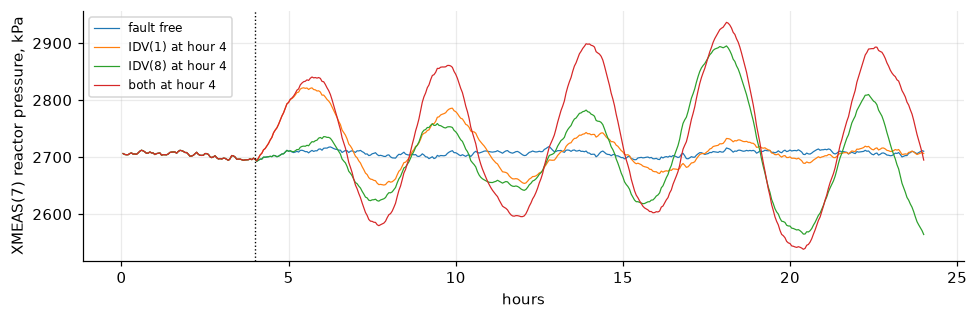

after hour 6                    mean       sd     max
  fault free                2706.89    4.737  2718.61
  IDV(1) at hour 4          2709.58   31.502  2808.84
  IDV(8) at hour 4          2702.19   79.371  2895.04
  both at hour 4            2731.92  113.072  2936.40

sum of the two individual pressure shifts predicts 2704.87 kPa; the pair gives 2731.92


In [6]:
cases = {"fault free": edited(base, hours="24", events=""),
         "IDV(1) at hour 4": edited(base, hours="24", events="4:start:1"),
         "IDV(8) at hour 4": edited(base, hours="24", events="4:start:8"),
         "both at hour 4": edited(base, hours="24", events="4:start:1,4:start:8")}
composed = {name: tep.Simulation(s).run() for name, s in cases.items()}

fig, ax = plt.subplots(figsize=(9, 3.0))
for name, r in composed.items():
    ax.plot(r.hours, r.measurement(7), lw=0.8, label=name)
ax.axvline(4.0, color="k", ls=":", lw=0.9)
ax.set_xlabel("hours")
ax.set_ylabel("XMEAS(7) reactor pressure, kPa")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print("after hour 6                    mean       sd     max")
for name, r in composed.items():
    after = r.hours >= 6.0
    p = r.measurement(7)[after]
    print("  %-24s %8.2f %8.3f %8.2f" % (name, p.mean(), p.std(), p.max()))

singles = [composed["IDV(1) at hour 4"], composed["IDV(8) at hour 4"]]
free = composed["fault free"]
after = free.hours >= 6.0
predicted = sum((r.measurement(7)[after].mean() - free.measurement(7)[after].mean())
                for r in singles) + free.measurement(7)[after].mean()
actual = composed["both at hour 4"].measurement(7)[after].mean()
print()
print("sum of the two individual pressure shifts predicts %.2f kPa; the pair gives %.2f"
      % (predicted, actual))

## Continuous magnitudes

This is the one the original cannot express at all. In `teprob.f` an `IDV` value is forced
to 0 or 1 before it is used, so "half of `IDV(4)`" is not a run you can ask for. That is a
real limitation for anyone studying detection thresholds, since the interesting question
is rarely "can you see a 5 C step" but "how small a step can you see".

Because it is a departure from the original rather than an addition on top of it, it is
behind an explicit flag. Ask for a fractional magnitude without setting `continuous=1` and
the scenario is refused, with a message naming the line of Fortran that makes it
impossible. It is not silently rounded, which would produce a dataset that looks fine and
is not the one you asked for.

In [7]:
try:
    edited(base, events="6:magnitude:4:0.5")
except ValueError as error:
    print("refused:", error)

allowed = edited(base, continuous="1", events="6:magnitude:4:0.5")
print()
print("allowed:", allowed.to_text())

refused: the scenario parsed but cannot run: a fractional magnitude without `continuous=1`, which the original cannot express: `teprob.f:341-346` forces every IDV to 0 or 1

allowed: tepsim.scenario.v1;seed=4651207995;hours=18;step=2.777777777777778e-4;every=180;faults=;controlled=1;idv12=0;trip=1;continuous=1;integrator=euler;events=6:magnitude:4:0.5


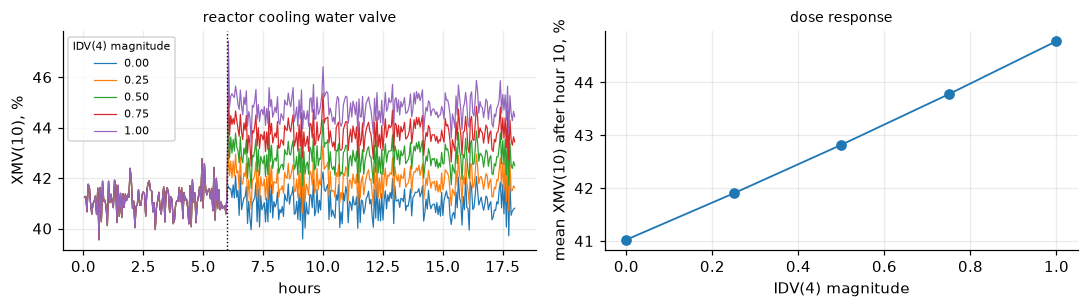

magnitude   XMV(10) mean   shift from zero   XMEAS(9) mean
   0.00         41.023           +0.000        120.4000
   0.25         41.902           +0.878        120.3999
   0.50         42.818           +1.795        120.3999
   0.75         43.777           +2.753        120.3999
   1.00         44.779           +3.755        120.3999

the response is linear in the magnitude to within 0.0419 % of valve travel


In [8]:
doses = [0.0, 0.25, 0.5, 0.75, 1.0]
dosed = {m: tep.Simulation(edited(base, hours="18", continuous="1",
                                  events="6:magnitude:4:%g" % m)).run()
         for m in doses}

fig, axes = plt.subplots(1, 2, figsize=(10, 2.9))
for m, r in dosed.items():
    axes[0].plot(r.hours, r.manipulated(10), lw=0.8, label="%.2f" % m)
axes[0].axvline(6.0, color="k", ls=":", lw=0.9)
axes[0].set_xlabel("hours")
axes[0].set_ylabel("XMV(10), %")
axes[0].set_title("reactor cooling water valve", fontsize=9)
axes[0].legend(fontsize=7, title="IDV(4) magnitude", title_fontsize=7)

after = {m: r.hours >= 10.0 for m, r in dosed.items()}
means = [dosed[m].manipulated(10)[after[m]].mean() for m in doses]
axes[1].plot(doses, means, "o-", lw=1.2)
axes[1].set_xlabel("IDV(4) magnitude")
axes[1].set_ylabel("mean XMV(10) after hour 10, %")
axes[1].set_title("dose response", fontsize=9)
fig.tight_layout()
plt.show()

print("magnitude   XMV(10) mean   shift from zero   XMEAS(9) mean")
for m in doses:
    r = dosed[m]
    mask = after[m]
    print("   %.2f        %7.3f          %+7.3f        %.4f"
          % (m, r.manipulated(10)[mask].mean(),
             r.manipulated(10)[mask].mean() - means[0],
             r.measurement(9)[mask].mean()))

slope = np.polyfit(doses, means, 1)
print()
print("the response is linear in the magnitude to within %.4f %% of valve travel"
      % np.abs(np.polyval(slope, doses) - means).max())

The dose response is clean and very nearly linear, and the reactor temperature in the last
column does not move at any magnitude: the controller absorbs the whole disturbance into
the valve. That is the same story notebook 1 told about the full-strength fault, now with a
knob on it, which is what makes it usable as an experiment. A detection threshold study is
now a sweep over one number rather than an argument about what "harder" means.

## Integrators

The original integrates with fixed-step explicit Euler at one second, and so does this port
by default, because that is the only choice under which the port is bit-identical to the
Fortran. Every claim the validation ladder makes is a claim about Euler.

Offering anything else is not trivial, and the reason is worth understanding before using
it. The original's right-hand side is not a pure function of the state: each call also
advances the disturbance walks, draws measurement noise, ticks the sampled analysers and
latches valve positions. That is harmless for Euler, which evaluates it once per step, and
it makes every multi-stage method wrong, because RK4 would advance the walks four times per
step. This port splits the step into an impure phase that runs once, a pure derivative that
runs as many times as the method needs, and a second impure phase that runs once. So all
three methods below see the same disturbance realisation and the same noise, and the only
difference between them is the integration.

In [9]:
day = tep.Scenario.baseline(hours=24)
methods = {}
for name in ("euler", "rk4", "dopri5"):
    scenario = edited(day, integrator=name)
    start = time.perf_counter()
    methods[name] = tep.Simulation(scenario).run()
    elapsed = time.perf_counter() - start
    print("%-7s %5.2f s   digest %s   XMEAS(7) at 24 h = %.6f"
          % (name, elapsed, scenario.digest, methods[name].measurement(7)[-1]))

reference = methods["dopri5"].to_numpy()
names = tep.channel_names()
print()
for name in ("euler", "rk4"):
    difference = np.abs(methods[name].to_numpy() - reference)
    scale = np.abs(reference).mean(axis=0)
    relative = difference / np.where(scale > 0, scale, 1.0)
    worst = int(np.unravel_index(difference.argmax(), difference.shape)[1])
    print("%-7s largest difference from dopri5 over 24 h: %.4g on %s, "
          "%.3g of that channel's mean; largest relative difference %.3g"
          % (name, difference.max(), names[worst],
             difference.max() / scale[worst], relative.max()))

euler    0.38 s   digest 60bb20cedccc9d46   XMEAS(7) at 24 h = 2710.290771


rk4      0.75 s   digest 621033772c7cbe0c   XMEAS(7) at 24 h = 2710.287538


dopri5   1.14 s   digest 980d1d53d6855fdb   XMEAS(7) at 24 h = 2710.287538

euler   largest difference from dopri5 over 24 h: 1.376 on XMEAS_3_E_feed, 0.000305 of that channel's mean; largest relative difference 0.0146
rk4     largest difference from dopri5 over 24 h: 0.0002991 on XMEAS_19_stripper_steam_flow, 1.28e-06 of that channel's mean; largest relative difference 2.08e-06


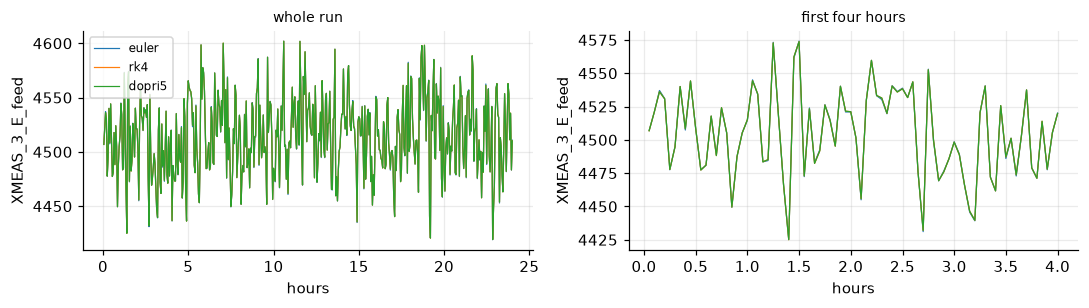

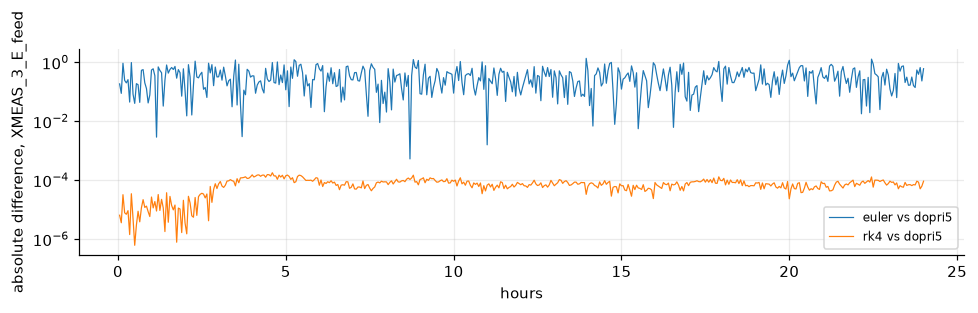

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 2.9))
channel = 2                                   # XMEAS(3), E feed
for ax, span in zip(axes, [slice(None), slice(0, 80)]):
    for name, r in methods.items():
        ax.plot(r.hours[span], r.to_numpy()[span, channel], lw=0.8, label=name)
    ax.set_xlabel("hours")
    ax.set_ylabel(names[channel])
axes[0].set_title("whole run", fontsize=9)
axes[1].set_title("first four hours", fontsize=9)
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

difference = np.abs(methods["euler"].to_numpy() - reference)
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.semilogy(methods["euler"].hours, difference[:, channel] + 1e-16, lw=0.8,
            label="euler vs dopri5")
ax.semilogy(methods["rk4"].hours,
            np.abs(methods["rk4"].to_numpy() - reference)[:, channel] + 1e-16, lw=0.8,
            label="rk4 vs dopri5")
ax.set_xlabel("hours")
ax.set_ylabel("absolute difference, %s" % names[channel])
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

Euler at a one-second step differs from the fifth-order solution by up to about one and a
half percent on the worst channel, which is small in absolute terms and four orders of
magnitude larger than the difference between RK4 and Dormand-Prince. Two independent methods agreeing that closely with each other and
disagreeing with the third is what convergence looks like: RK4 and Dormand-Prince have
converged and Euler has not.

Euler is not the accurate choice, it is the *faithful* one, and the distinction is the
whole point of offering all three. If you are validating against the Fortran or
reproducing published data, use Euler, because everything the validation ladder claims is
a claim about Euler. If you are studying the plant as a dynamical system, RK4 costs about
twice as much wall clock and is a genuinely better integration of the same equations.

### The trap: you cannot refine the step

The obvious next move is to keep Euler and halve the step. It does not do what you expect,
and it is better to see why than to discover it in a result.

In [11]:
STEP_1S = "2.777777777777778e-4"
refinements = [(STEP_1S, "180", "1 s"),
               ("1.3888888888888889e-4", "360", "0.5 s"),
               ("6.944444444444444e-5", "720", "0.25 s")]

print("euler, sampled every 180 seconds either way")
print("  step     samples   XMEAS(7) at 24 h    XMEAS(7) mean")
for step, every, label in refinements:
    r = tep.Simulation(edited(day, integrator="euler", step=step, every=every)).run()
    print("  %-7s  %6d    %12.5f     %12.5f"
          % (label, len(r), r.measurement(7)[-1], r.measurement(7).mean()))

print()
print("for comparison, changing the method at a fixed 1 s step")
for name in ("euler", "rk4", "dopri5"):
    r = methods[name]
    print("  %-7s  %6d    %12.5f     %12.5f"
          % (name, len(r), r.measurement(7)[-1], r.measurement(7).mean()))

euler, sampled every 180 seconds either way
  step     samples   XMEAS(7) at 24 h    XMEAS(7) mean


  1 s         480      2710.29077       2706.25942


  0.5 s       480      2720.35331       2706.06776


  0.25 s      480      2715.87378       2702.64710

for comparison, changing the method at a fixed 1 s step
  euler       480      2710.29077       2706.25942
  rk4         480      2710.28754       2706.27522
  dopri5      480      2710.28754       2706.27523


Halving the step moves the answer by more than changing the integrator does, and it does
not converge as the step shrinks. That is not a bug and it is not stiffness. The
disturbance walks and the measurement noise advance once per *step*, so a run at half the
step draws twice as many random numbers and is a different realisation of the stochastic
forcing. It is a different experiment, not a more accurate version of the same one.

The practical rule is that the step size is part of the disturbance model in this plant and
not only a numerical parameter. Change the method to integrate the same realisation more
accurately; change the step only when you mean to change the noise.

## Reproducing a run from its description

Every scenario built in this notebook can be printed, and every one parses back to an equal
scenario with an identical digest. That is the property that makes a dataset checkable: a
file shipped with its scenario text can be regenerated and compared, rather than trusted.

In [12]:
built = {"baseline 18 h": base,
         "IDV(4) 6 to 12 h": window,
         "IDV(1) and IDV(8) at 4 h": cases["both at hour 4"],
         "half-strength IDV(4)": edited(base, hours="18", continuous="1",
                                        events="6:magnitude:4:0.5"),
         "rk4, 24 h": edited(day, integrator="rk4"),
         "0.5 s euler, 24 h": edited(day, step="1.3888888888888889e-4", every="360")}

print("%-26s %-18s %s" % ("scenario", "digest", "round-trips"))
for name, s in built.items():
    print("%-26s %-18s %s"
          % (name, s.digest, tep.Scenario.from_text(s.to_text()) == s))

print()
print("and the same digest is reached from the text alone, with no Python object involved:")
text = built["half-strength IDV(4)"].to_text()
print(" ", text)
print("  digest", tep.Scenario.from_text(text).digest)

scenario                   digest             round-trips
baseline 18 h              64aa88e3de5cf13c   True
IDV(4) 6 to 12 h           77796f4123c9ca6f   True
IDV(1) and IDV(8) at 4 h   b4af40dc554347eb   True
half-strength IDV(4)       98140e194f3348e8   True
rk4, 24 h                  621033772c7cbe0c   True
0.5 s euler, 24 h          74709586ccf4fe61   True

and the same digest is reached from the text alone, with no Python object involved:
  tepsim.scenario.v1;seed=4651207995;hours=18;step=2.777777777777778e-4;every=180;faults=;controlled=1;idv12=0;trip=1;continuous=1;integrator=euler;events=6:magnitude:4:0.5
  digest 98140e194f3348e8


In [13]:
one = tep.Simulation(tep.Scenario.from_text(text)).run().to_numpy()
two = tep.Simulation(tep.Scenario.from_text(text)).run().to_numpy()
print("two runs from the same text are bit-identical:", np.array_equal(one, two))
print("largest difference:", np.abs(one - two).max())

two runs from the same text are bit-identical: True
largest difference: 0.0


## Summary

The four extensions in this notebook are all in the same spirit: the original expresses a
run as a set of flags plus whatever the operator remembers, and this port expresses it as a
value that can be printed, hashed, sent in a link and parsed back. Schedules, composition
and continuous magnitudes are new experiments the original cannot describe; the choice of
integrator is a departure from it that says so in the scenario rather than in a comment.

The two extensions that change the numerics, `continuous` and any integrator other than
`euler`, are both visible in the scenario text and both change the digest, so a result
produced with them can never be mistaken for one produced without.

## References

- J. J. Downs and E. F. Vogel, "A plant-wide industrial process control problem",
  *Computers & Chemical Engineering* **17**(3), 245-255 (1993).
  doi:10.1016/0098-1354(93)80018-I
- N. L. Ricker, "Decentralized control of the Tennessee Eastman challenge process",
  *Journal of Process Control* **6**(4), 205-221 (1996).
  doi:10.1016/0959-1524(96)00031-5
- A. Bathelt, N. L. Ricker and M. Jelali, "Revision of the Tennessee Eastman process
  model", *IFAC-PapersOnLine* **48**(8), 309-314 (2015).
  doi:10.1016/j.ifacol.2015.08.199